# Dimensiereductie

Auteurs: Brian van der Bijl (brian.vanderbijl@hu.nl), Tijmen Muller

- Studentnummer: 1883023
- Naam: Mohammed el Atrach
- Datum: 03-03-2026

## Deel I: Principal Component Analysis (PCA)

Het _Principal Component Analysis_ (PCA) algoritme kan gebruikt worden om het aantal dimensies van een dataset te reduceren tot de belangrijkste componenten. Als de originele dataset $n$ dimensies heeft, dan kunnen we met onderstaande stappen dit terugbrengen tot een (zelfgekozen) aantal van $n^\prime$ dimensies.

1. Centreer de data.
2. Bereken de covariantie van alle features onderling. 
3. Bereken de Eigenvectors en Eigenvalues van de covariantiematrix.
4. Kies de $n^\prime$ Eigenvectors om de dimensiereductie mee uit te voeren.
5. Vermenigvuldig de $n^\prime$ Eigenvectors met de originele data om de reductie toe te passen.

### Context

Gegeven is een databestand met embeddings van 200 tekstfragmenten. Elke embedding bestaat in 15 dimensies, en is gelabeled met een categorie. We gaan dimensionaliteitsreductie toepassen om de data te kunnen plotten.

De categorie geeft aan in welk genre de tekstfragmenten thuishoren. Daarnaast is onderscheid gemaakt tussen het perspectief waarin het fragment geschreven is: ik (1st person) of hij/haar/hen (3rd person):
- Fantasy (1st person)
- Fantasy (3rd person)
- Science Fiction (1st person)
- Science Fiction (3rd person)
- Romance (1st person)
- Romance (3rd person)
- Crime (1st person)
- Crime (3rd person)

In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

# Show floats on 3 digits, suppress scientific notation
np.set_printoptions(precision=3, suppress=True)

In [2]:
with open('data.pkl', 'rb') as file:
    data = pickle.load(file)

data.sample(5)

e_1,e_2,e_3,e_4,e_5,e_6,e_7,e_8,e_9,e_10,e_11,e_12,e_13,e_14,e_15,label
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
1.087314,1.014294,0.065063,0.604195,0.956857,6.0885,0.425903,3.550973,1.10491,0.775839,0.883332,0.966261,0.810213,1.710712,0.954009,"""Crime (3rd person)"""
1.299649,0.59555,0.689233,0.92493,1.079483,3.06413,0.853903,2.999948,0.935744,1.304642,1.198628,1.289262,0.846259,0.854524,1.051545,"""Fantasy (3rd person)"""
1.366662,0.428525,1.013596,0.960052,1.294279,2.032631,0.763559,3.308938,1.417092,0.499803,1.005871,0.819688,0.832679,1.018665,1.030184,"""Science Fiction (1st person)"""
0.40468,1.382485,0.728102,0.847107,0.626194,3.668179,1.539478,2.396185,1.338528,0.998645,1.335997,0.568576,1.530084,0.828038,1.286878,"""Science Fiction (3rd person)"""
1.494548,1.008475,0.809099,1.009756,0.901573,6.134289,1.223422,0.735326,0.607192,1.208952,0.68226,0.240274,0.66263,0.599785,0.262245,"""Romance (1st person)"""


### Voorbereidende opdracht

Gegeven een dataset met $m$ datapunten met elk $n$ features en een gewenste reductie tot $n^\prime$ dimensies. Bepaal voor elk van de vijf stappen van het algoritme wat de dimensies (oftewel `shape`) is van de volgende tussenresultaten:

0. De matrix met de originele dataset.
1. De matrix met de gemiddelden per feature om de data mee te centreren.
2. De covariantiematrix.
3. De matrix met de Eigenvectors en de matrix met de Eigenvalues.
4. De matrix met de _geselecteerde_ Eigenvectors.
5. De matrix met de _gereduceerde_ data.

0. ($m$, $n$)
1. (1, $n$)
2. ($n$, $n$)
3. eigenvalues = (1, $n$), eigenvectors = ($n$, $n$)
4. ($n$, $n^\prime$)
5. ($m$, $n^\prime$)

### Opdracht 1. Implementatie

Schrijf een eigen implementatie van het PCA-algoritme `compute_pca(X, n_components)` volgens eerdergenoemde stappen van het algoritme. Maak slim gebruik van fucties van `numpy` waar mogelijk, maar zorg wel dat je begrijpt wat je in elke stap doet. De laatste stap is al gegeven in de functiedefinitie hieronder.

Hint: Laat bij stap 3. zien (bijvoorbeeld met een `print()` statement) dat de meest informatieve Eigenvalue al meer dan 50% van de informatie bevat van onze dataset.

#### Input
- `X: numpy.array` - numpy matrix met dimensies $(m, n)$; elke rij is een datapunt in $n$ dimensies
- `n_components: int` - het gewenste aantal dimensies $n^\prime$

#### Output
`X_reduced: numpy.array` - een $(m, n^\prime)$ numpy matrix met de gereduceerde data.

In [3]:
def compute_pca(X, n_components):
    """
    Parameters
    ----------
    X : numpy.ndarray
        Input data matrix of shape (m, n), where m is the number of samples and n is the number of features.
    n_components : int
        The number of principal components (dimensions) to keep.

    Returns
    -------
    X_reduced : numpy.ndarray
        The data projected onto the top n_components principal components.
    """
    arr = np.array(X)

    # centeren van de data
    gemiddelde_per_feature = arr.mean(axis=0)  # gemiddelde van elke kolom
    arr = arr - gemiddelde_per_feature

    covariantiematrix = np.cov(arr, rowvar=False)

    eigenwaarden, eigenvectoren = np.linalg.eigh(covariantiematrix)

    # eigenwaarden en eigenvectoren sorteren/ranken van groot naar klein
    sort_i = np.argsort(eigenwaarden)[::-1]
    eigenwaarden = eigenwaarden[sort_i]
    eigenvectoren = eigenvectoren[:, sort_i]


    # de gewenste dimensies selecteren
    n_eigenvectors = eigenvectoren[:, :n_components]


    # percentage hoeveel variantie er nog in zit
    acc = eigenwaarden[:n_components].sum() / eigenwaarden.sum()

    # Stap 5.
    return arr @ n_eigenvectors, acc

#### Test-scenario
Onderstaande code zou de volgende output moeten opleveren (het minteken kan wisselen):

```python
[[ 0.43437323 -0.49820384]
 [ 0.42077249  0.50351448]
 [-0.85514571 -0.00531064]]
 ```

In [4]:
np.random.seed(1)
X = np.random.rand(3, 10)
X_reduced = compute_pca(X, n_components=2)
print(X_reduced)

(array([[ 0.434,  0.498],
       [ 0.421, -0.504],
       [-0.855,  0.005]]), np.float64(0.9999999999999999))


### Opdracht 2. Visualisatie met dimensiereductie

Maak op basis van de aangeleverde `data` een numpy array van de datapunten, en gebruik je PCA-implementatie om een 2D- en 3D-weergave van de data te maken. Maak van elke weergave een plot, waarbij iedere categorie een eigen kleur krijgt.

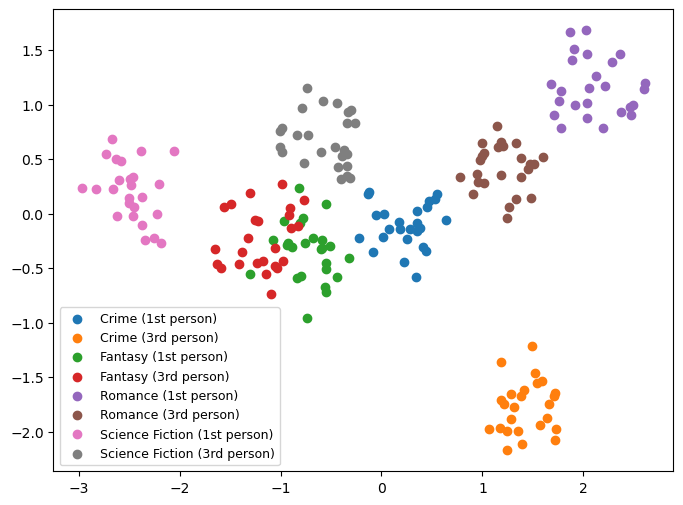

In [5]:
# omzetten naar numpy
labels = data.select(data.columns[-1]).to_numpy().flatten() # label
X = data.select(data.columns[:-1]).to_numpy().astype(float) # features

# PCA toepassen en reduceren naar 2 dimensies om te kunnen plotten
X2, acc2 = compute_pca(X, 2) # X2 zijn de nieuwe "coördinaten"

unique_labels = np.unique(labels)
plt.figure(figsize=(8, 6))
for lab in unique_labels:
    idx = labels == lab
    plt.scatter(X2[idx, 0], X2[idx, 1], label=lab)

plt.legend(fontsize=9)

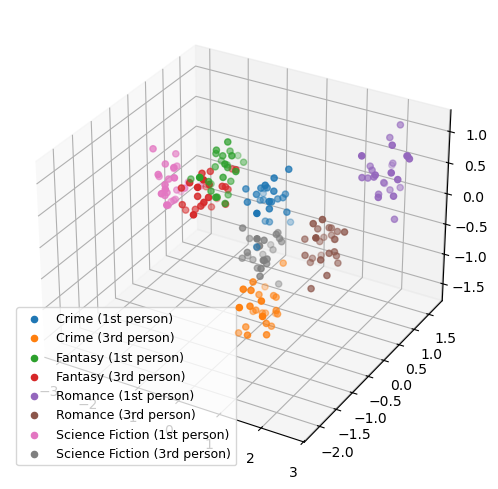

In [6]:
X3, acc3 = compute_pca(X, 3)

# 3D scatterplot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
unique_labels = np.unique(labels)
for lab in unique_labels:
    idx = labels == lab
    ax.scatter(X3[idx, 0], X3[idx, 1], X3[idx, 2], label=lab)
plt.legend(fontsize=9)

### Opdracht 3. Analyse

Analyseer de resultaten:
1. Welke categorieën zijn op basis van de PCA-reductie te onderscheiden, en welke niet? 
2. Geef aan hoeveel procent van de informatie bewaard is gebleven in 2D en 3D respectievelijk.
3. Hoeveel dimensies zijn nodig om 90% van de informatie te bewaren?
4. En voor 95%?

1. In 2D is bijna alles goed te onderscheiden, behalve Fantasy 1st en 3rd, want die liggen dicht op elkaar. In 3D zie je opnieuw dat Fantasy 1st en 3rd lastig te scheiden zijn, en daar komt bij dat Science Fiction 1st deels overlapt met Fantasy. Daarnaast zie je in 3D dat Science Fiction 3rd overlapt met Crime 1st en 3rd, waardoor die groepen ook moeilijk uit elkaar te halen zijn.

In [7]:
#2
acc2

np.float64(0.6866656218830465)

2.
- In 2D blijft 68.7% van de totale informatie behouden

In [8]:
#2
acc3

np.float64(0.7721763602652282)

2.
- In 3D blijft 77.2% van de totale informatie behouden

In [9]:
#3
for i in range(1,10):
    dum, acc = compute_pca(X, i)
    if acc >= 0.9:
        print(f"Er zijn {i} dimensies nodig om {acc} van de informatie te behouden")
        break

Er zijn 7 dimensies nodig om 0.9049017075553294 van de informatie te behouden


In [10]:
#4
for i in range(1,15):
    dum, acc = compute_pca(X, i)
    if acc >= 0.95:
        print(f"Er zijn {i} dimensies nodig om {acc} van de informatie te behouden")
        break


Er zijn 11 dimensies nodig om 0.9616681690332414 van de informatie te behouden


## Deel II: t-Distributed Stochastic Neighbour Embedding (t-SNE)

Een alternatieve methode voor dimensiereductie is _t-Distributed Stochastic Neighbour Embedding_ (t-SNE). 

### Opdracht 4. Toepassing
Gebruik SciKit-Learn om met behulp van t-SNE de data tot 2 dimensies te reduceren en plot het resultaat (wederom met kleuren voor de categorien).

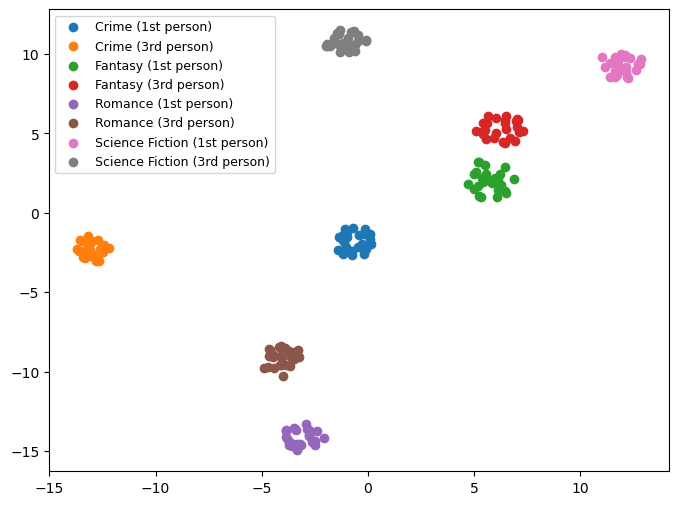

In [11]:
from sklearn.manifold import TSNE

# omzetten naar numpy
labels = data.select(data.columns[-1]).to_numpy().flatten() # label
X = data.select(data.columns[:-1]).to_numpy().astype(float) # features

# t-SNE toepassen en reduceren naar 2 dimensies om te kunnen plotten
tsne = TSNE(n_components=2)
X_embedded = tsne.fit_transform(X) # X_embedded zijn de nieuwe "coördinaten"

unique_labels = np.unique(labels)
plt.figure(figsize=(8, 6))
for lab in unique_labels:
    idx = labels == lab
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1], label=lab)

plt.legend(fontsize=9)

### Opdracht 5. Vergelijking

Vergelijk deze met de resultaten van je PCA-implementatie:

1. Hoe verhoudt de zichtbaarheid van de categorieën zich tussen beide resultaten?
2. Hoe verhouden de algoritmes zich in het behoud van informatie?

Beantwoord de volgende vragen los van de data van deze opdracht:

3. Waarvoor zou je PCA en t-SNE inzetten als je te maken krijgt met een onbekende (mogelijk ongelabelde) dataset?
4. Geef een voorbeeld waar PCA de voorkeur heeft boven t-SNE.
5. Geef een voorbeeld waar t-SNE de voorkeur heeft boven PCA.

1. Bij PCA konden we de meeste categorieën uit elkaar houden, maar er bleven clusters die elkaar overlapten, zoals Fantasy 1st en Fantasy 3rd. In 3D kwam daar nog bij dat Science Fiction 1st deels overlapt met Fantasy. Bij t‑SNE zie je daarentegen in 1 oogopslag welke categorie bij welke hoort, en is er geen overlap.
2. Bij PCA bleef in 2D 68,7% van alle informatie behouden, waardoor je de belangrijkste structuur nog duidelijk terugziet. t‑SNE focust vooral op lokale afstanden en verliest daardoor de globale informatie. Je krijgt dus een mooie visualisatie, maar niet dezelfde hoeveelheid echte informatie als bij PCA.

3. PCA kan je gebruiken om een eerste beeld te krijgen van de globale structuur van de dataset en om lineaire verbanden te ontdekken. t‑SNE kan je gebruiken om te kijken of er clusters of subclusters aanwezig zijn. Beide technieken helpen om een onbekende dataset beter te verkennen.
4. PCA kan je gebruiken wanneer je van veel verschillende kenmerken een paar duidelijke hoofdlijnen wilt maken. Een voorbeeld dat ook in de les genoemd werd, is de PCA‑plot van de stemwijzer waarbij alle partijen netjes op een links‑rechts en progressief‑conservatief as terechtkomen. Zo'n soort overzicht krijg je niet met t‑SNE die kijkt vooral lokaler om iets te clusteren.
5. Als je heel veel klantprofielen hebt en wilt ontdekken of er duidelijke klantgroepen bestaan op basis van gedrag, dan werkt t‑SNE beter. t‑SNE laat namelijk duidelijk zien welke klanten dicht bij elkaar liggen en welke groepen van elkaar verschillen.

### Opdracht 6. Project

Als het goed is, heb je op dit moment een eerste idee van de data waar je in het project mee gaat werken. Geef antwoord op onderstaande vragen.

1. Wat is de dimensionaliteit waar je mee te maken hebt?
2. Beschrijf hoe dimensionaliteitsreductie-algoritmen je kunnen helpen de data te verkennen.

1. In het project krijgen we een dataset met foto's van de binnenkant van een tank. Elke foto bestaat uit een enorme hoeveelheid pixels, en elke pixel is in principe een dimensie. Omdat het 4K‑foto's zijn, praten we over miljoenen dimensies per foto. Het is dus extreem hoge‑dimensionale data.

2. Dimensionaliteitsreductie zou ons vooral helpen om een eerste beeld te krijgen van hoe onze data eruitziet. We kunnen ermee zien of foto's met hetzelfde label (pitting, beschadigingen, krassen, verkleuring) bij elkaar in de buurt liggen, dus of er clusters ontstaan. Zo zien we meteen of de labels logisch van elkaar gescheiden zijn en of er binnen een label misschien ook nog subclusters zitten. Daarnaast kunnen we ook een inschatting maken van hoe moeilijk de segmentatie gaat worden. Als verschillende soorten schade in de lage‑dimensionale ruimte helemaal door elkaar heen liggen, is dat een teken dat het model moeite zal krijgen om ze te scheiden en te segmenteren. Ook kunnen we foto's die we eigenlijk niet kunnen gebruiken opsporen. Foto's met bijvoorbeeld slechte belichting of veel reflectie zullen waarschijnlijk in een PCA of t‑SNE plot buiten de rest van de groep vallen.